<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
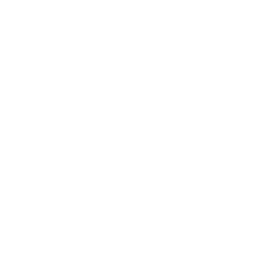
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klyngeinddeling af bygningers energieffektivitet</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energi / bæredygtighedsanalyse &nbsp;|&nbsp; marts 2026</p>
</div>
</div>
</div>

## Sammenfatning

Dette gennemarbejdede eksempel klynger en portefølje af erhvervsbygninger efter fem energieffektivitetsmetrikker — energiforbrugsintensitet (EUI), HVAC-effektivitetsforhold, klimaskærmens termiske modstand, belysningseffekttæthed og andel vedvarende energi — for at afdække tydelige performanceniveauer til målretning af forsyningstilskud. Analysen bruger **PROC FASTCLUS** med `REPLACE=FULL` (fuld sædeudskiftning) og sammenligner k=3, 4, 5 og 6-løsninger på samlet R-kvadreret, pseudo-F-statistikken og mindste klyngestørrelse. k=4-løsningen profileres derefter i detaljer, og hver klynge kortlægges til et handlingsorienteret effektivitetsniveau. Fordi dette miljø kører uden licens, er demonstrationen afgrænset til en stikprøve på 100 bygninger; det samme program skalerer uændret til en fuld portefølje.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|---------|
| WORK.BUILDING_METRICS | Årlige energieffektivitetsmetrikker pr. bygning (syntetisk) | 100 |


---

In [1]:
data work.building_metrics;
    CALL streaminit(42);
    TABEL btypes[5] $15 _temporary_ ('KONTOR' 'BUTIK' 'LAGER' 'HOSPITAL' 'SKOLE');
    TABEL regions[4] $12 _temporary_ ('NORDOEST' 'SYDOEST' 'MIDTVESTEN' 'VEST');
    GØR building_id = 1 TIL 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        building_type = btypes[type_idx];
        reg_idx = int(rand('uniform') * 4) + 1;
        climate_region = regions[reg_idx];

        /* Energiforbrugsintensitet, EUI (kBtu/sqft/år) */
        eui = round(rand('normal', 85, 35), 0.1);
        HVIS eui < 15 SÅ eui = 15;
        HVIS eui > 250 SÅ eui = 250;

        /* HVAC-effektivitetsforhold (COP-ækvivalent) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        HVIS hvac_efficiency < 1.0 SÅ hvac_efficiency = 1.0;
        HVIS hvac_efficiency > 6.0 SÅ hvac_efficiency = 6.0;

        /* Klimaskærmens termiske modstand (R-værdi) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        HVIS envelope_r_value < 5 SÅ envelope_r_value = 5;
        HVIS envelope_r_value > 40 SÅ envelope_r_value = 40;

        /* Belysningseffekttæthed (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        HVIS lighting_wpf < 0.3 SÅ lighting_wpf = 0.3;
        HVIS lighting_wpf > 2.5 SÅ lighting_wpf = 2.5;

        /* Andel vedvarende energi */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        HVIS renewable_pct > 80 SÅ renewable_pct = 80;

        /* Bygningsalder i år */
        building_age = int(rand('uniform') * 80) + 1;

        /* Bruttoareal (tusinde sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        HVIS floor_area_ksf > 500 SÅ floor_area_ksf = 500;

        UDDATA;
    SLUT;
    FJERN type_idx reg_idx;
KØR;



NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.56 seconds
  cpu   1.56 seconds


---


In [2]:
PROCEDURE GENNEMSNIT data=work.building_metrics n mean std;
    KLASSE building_type;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    MÆRKAT building_type="Bygningstype" eui="EUI (kBtu/sqft/år)"
          hvac_efficiency="HVAC-effektivitet (COP)" envelope_r_value="Klimaskærm (R-værdi)"
          lighting_wpf="Belysning (W/sqft)" renewable_pct="Vedvarende andel (%)";
    TITEL "Energimetrikker efter bygningstype";
KØR;


                                           Energimetrikker efter bygningstype                                           

                                                  The MEANS Procedure

                                      Analysis Variable : eui EUI (kBtu/sqft/år)

        Bygningstype          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        BUTIK                    16     79.7312500     42.6818106
        HOSPITAL                 25     87.9040000     35.2632892
        KONTOR                   20     73.0550000     40.3950163
        LAGER                    20     90.8900000     33.5993249
        SKOLE                    19     89.7000000     39.0498542
        ---------------------------------------------------------

                              Analysis Variable : hvac_efficiency HVAC-effektivitet (COP)

        Bygningstype          N Obs           Mean        Std Dev
        -------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                           Energimetrikker efter bygningstype                                           




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


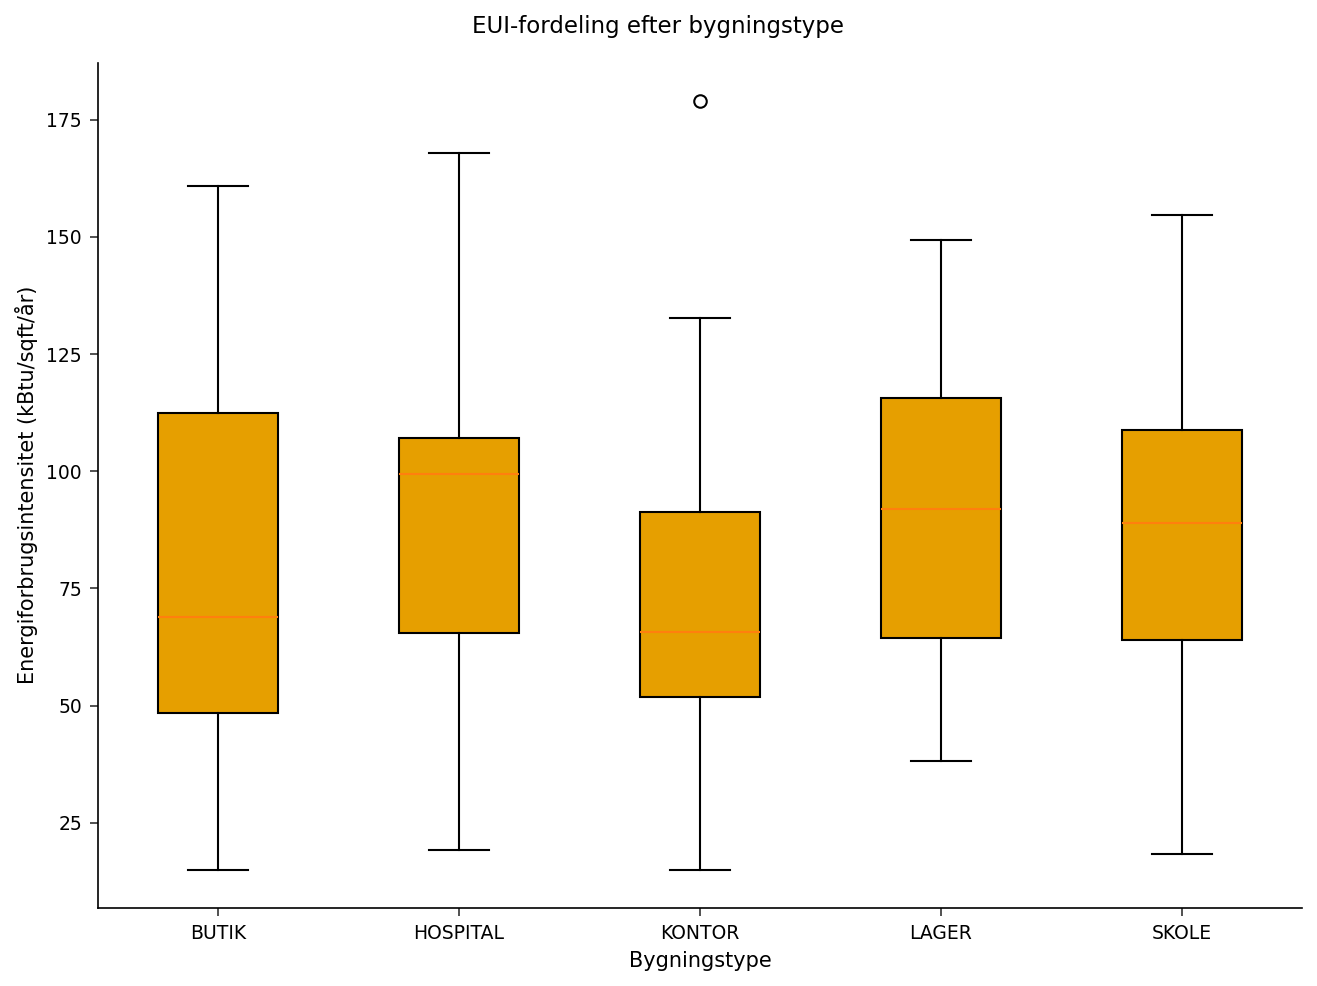

In [3]:
PROCEDURE SGPLOT data=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS MÆRKAT="Bygningstype";
    YAXIS MÆRKAT="Energiforbrugsintensitet (kBtu/sqft/år)";
    TITEL "EUI-fordeling efter bygningstype";
KØR;


---


In [4]:
PROCEDURE STANDARD data=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
KØR;



NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
PROCEDURE FASTCLUS data=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Bygningseffektivitetsklynger: k=3 REPLACE=FULL";
KØR;


                                           Energimetrikker efter bygningstype                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
PROCEDURE FASTCLUS data=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Bygningseffektivitetsklynger: k=4 REPLACE=FULL";
KØR;


                                           Energimetrikker efter bygningstype                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
PROCEDURE FASTCLUS data=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Bygningseffektivitetsklynger: k=5 REPLACE=FULL";
KØR;


                                           Energimetrikker efter bygningstype                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
PROCEDURE FASTCLUS data=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    TITEL "Bygningseffektivitetsklynger: k=6 REPLACE=FULL";
KØR;


                                           Energimetrikker efter bygningstype                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
%macro cluster_quality(k);
PROCEDURE FREKVENSER data=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (OMDØB=(count=n_buildings));
KØR;

PROCEDURE SQL NOPRINT;
    VÆLG MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);


                                           Energimetrikker efter bygningstype                                           

                                           Energimetrikker efter bygningstype                                           

                                           Energimetrikker efter bygningstype                                           

                                           Energimetrikker efter bygningstype                                           




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                    Effektivitetsprofiler for bygningsklynger (k=4)                                     

                                                  The MEANS Procedure

                                      Analysis Variable : eui EUI (kBtu/sqft/år)

                                                 N
                                     Klynge    Obs             Mean         Std Dev
                                     ----------------------------------------------
                                     1          23       63.7782609      31.5423086
                                     2          17      122.5941176      36.0679995
                                     3          26       94.0076923      30.8825378
                                     4          34       72.3911765      31.7411154
                                     ----------------------------------------------

                                      Analysis Variable : hvac_efficiency HVAC-effekt


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


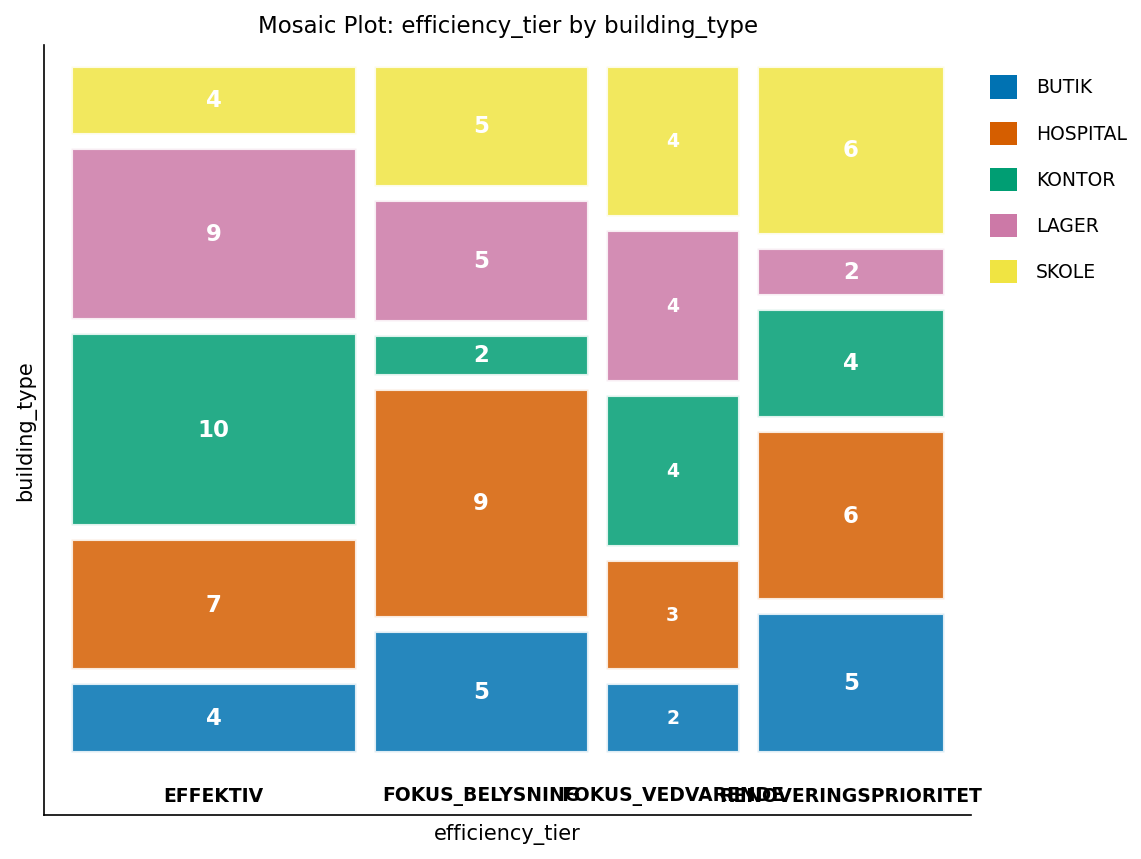

In [10]:
data work.bldg_profiled;
    SAMMENFLET work.building_metrics
          work.bldg_clust4 (BEHOLD=building_id CLUSTER distance);
    EFTER building_id;
KØR;

PROCEDURE GENNEMSNIT data=work.bldg_profiled mean std;
    KLASSE CLUSTER;
    VARIABEL eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    MÆRKAT CLUSTER="Klynge" eui="EUI (kBtu/sqft/år)"
          hvac_efficiency="HVAC-effektivitet (COP)" envelope_r_value="Klimaskærm (R-værdi)"
          lighting_wpf="Belysning (W/sqft)" renewable_pct="Vedvarende andel (%)"
          building_age="Bygningsalder (år)";
    TITEL "Effektivitetsprofiler for bygningsklynger (k=4)";
KØR;

/* Marker effektivitetsniveauer ud fra de observerede k=4-centroider:
   Klynge 4 = bedst HVAC (3.89) ved lav EUI  -> EFFEKTIV
   Klynge 2 = højest andel vedvarende (28%), men højest EUI -> FOKUS_VEDVARENDE
   Klynge 3 = højeste belysningsbelastning, svag HVAC, mid EUI -> FOKUS_BELYSNING
   Klynge 1 = lav EUI, men svagest HVAC + tyndeste klimaskærm -> RENOVERINGSPRIORITET */
data work.bldg_tiered;
    SÆT work.bldg_profiled;
    LÆNGDE efficiency_tier $24;
    HVIS CLUSTER = 4 SÅ efficiency_tier = 'EFFEKTIV';
    ELLERS HVIS CLUSTER = 2 SÅ efficiency_tier = 'FOKUS_VEDVARENDE';
    ELLERS HVIS CLUSTER = 3 SÅ efficiency_tier = 'FOKUS_BELYSNING';
    ELLERS HVIS CLUSTER = 1 SÅ efficiency_tier = 'RENOVERINGSPRIORITET';
KØR;

PROCEDURE FREKVENSER data=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    MÆRKAT efficiency_tier="Effektivitetsniveau" building_type="Bygningstype";
    TITEL "Effektivitetsniveau efter bygningstype";
KØR;


---


### Fortolkning

Med `REPLACE=FULL` konvergerede alle k-værdier rent. På tværs af de fire løsninger steg den samlede R-kvadreret monotont med k — 0.305 (k=3), 0.410 (k=4), 0.459 (k=5), 0.515 (k=6) — mens pseudo-F-statistikken toppede ved **k=4 (22.23)** før den faldt (20.13 ved k=5, 19.93 ved k=6). Kombineret med en mindste klyngestørrelse på 17 bygninger ved k=4 (mod 13 ved k=5 og 10 ved k=6) giver **k=4-løsningen** den bedste balance mellem adskillelse og niveaustabilitet, så det er den, der profileres nedenfor.

De fire k=4-klynger kortlægger til klart adskilte effektivitetsprofiler (gennemsnit fra PROC MEANS-profilen ovenfor):

- **Effektiv (Klynge 4, n=34):** den bedst udstyrede gruppe — højeste HVAC-effektivitet (COP 3.89) ved en lav-moderat EUI på 72.4 kBtu/sqft/år, med tilstrækkelig klimaskærm (R 18.8) og beskeden andel vedvarende energi (11.0%).
- **Fokus vedvarende (Klynge 2, n=17):** de højeste absolutte forbrugere (EUI 122.6), men også langt den højeste andel vedvarende energi (28.2%), med midt-i-feltet HVAC (COP 3.42). Højt forbrug kombineret med produktion på stedet.
- **Fokus belysning (Klynge 3, n=26):** mid-EUI (94.0) drevet af den højeste belysningseffekttæthed (1.35 W/sqft) og den næstsvageste HVAC (COP 2.42), på trods af den tykkeste klimaskærm (R 19.6).
- **Renoveringsprioritet (Klynge 1, n=23):** lav EUI på papiret (63.8), men svagest HVAC (COP 2.28) og tyndeste klimaskærm (R 12.5) — bygninger, der er små eller lidt brugte, men dårligt udstyrede, de klareste kandidater til klimaskærms- og HVAC-renoveringer.

Krydstabuleringen af niveau efter bygningstype viser, at kontorer (10) og lagre (9) dominerer det effektive niveau, mens hospitaler koncentrerer sig i niveauet fokus belysning (9 af 26). Niveauet renoveringsprioritet er spredt over typer, anført af hospitaler og skoler (6 hver af 23). I forhold til programdesign er de 23 renoveringsprioritets- og 26 fokus-belysnings-bygninger de naturlige mål for HVAC- og belysningstilskud, mens de 17 fokus-vedvarende-bygninger — der allerede producerer på stedet — er bedre egnede til forbrugsreduktion end til yderligere produktionstilskud.

---


In [11]:
PROCEDURE EKSPORTERE data=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
KØR;



NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>